In [71]:
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
data = pd.read_feather('../data/btc_train.feather')
#test_data = data.iloc[-200_000:]
feature_names = data.columns

In [73]:
features = data.dropna().values
scaler = StandardScaler()
X = scaler.fit_transform(features)

pca = PCA(n_components=15)
X = pca.fit_transform(X)

n_needed = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_needed}")

Number of components to explain 95% variance: 15



Top features for PC1:
donchian_upper    0.267159
ema_120           0.267157
ema_60            0.267156
donchian_mid      0.267156
ema_240           0.267156
Name: PC1, dtype: float64

Top features for PC2:
vwap_distance    0.340023
rsi_14           0.337884
stoch_d          0.331316
stoch_k          0.315610
macd             0.313492
Name: PC2, dtype: float64

Top features for PC3:
q_asset_volume         0.416538
volume                 0.416121
taker_buy_b_volume     0.313619
taker_buy_q_volume     0.313349
taker_sell_b_volume    0.305801
Name: PC3, dtype: float64

Top features for PC4:
buy_pressure           0.457401
taker_sell_q_volume    0.307751
taker_sell_b_volume    0.306674
taker_buy_q_volume     0.305609
taker_buy_b_volume     0.304485
Name: PC4, dtype: float64

Top features for PC5:
macd_hist              0.323433
vwap_distance_z        0.315313
buy_ratio_q_sma_60     0.301614
sell_ratio_q_sma_60    0.301614
buy_pressure_sma_60    0.274976
Name: PC5, dtype: float64

Top featu

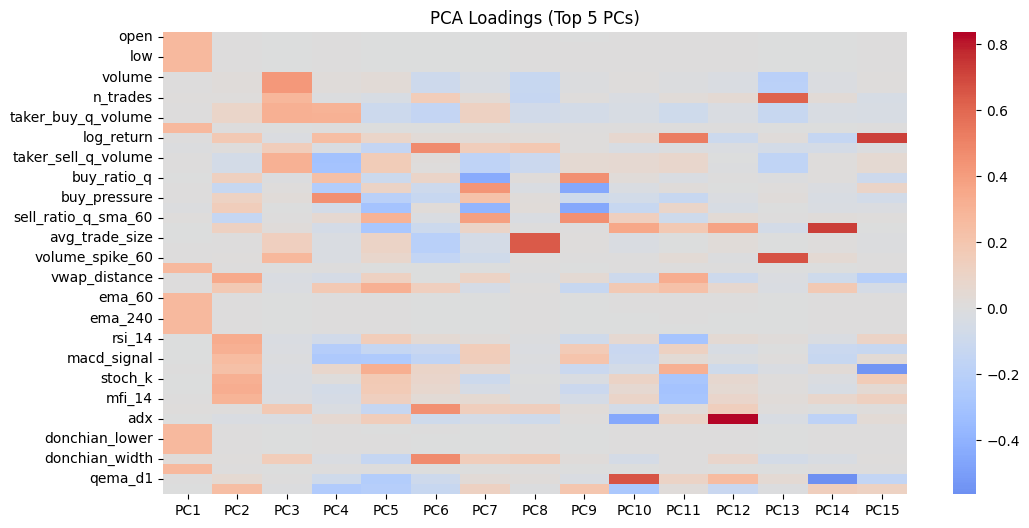

In [74]:
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(pca.n_components)],
                        index=feature_names)

for pc in loadings.columns:
    print(f"\nTop features for {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))

plt.figure(figsize=(12, 6))
sns.heatmap(loadings.iloc[:, :20], cmap="coolwarm", center=0)
plt.title("PCA Loadings (Top 5 PCs)")
plt.show()

In [75]:
model = GaussianHMM(n_components=3, covariance_type='full', n_iter=200)
model.fit(X)

GaussianHMM(covariance_type='full', n_components=3, n_iter=200)

State 0 total variance: 115.48
State 1 total variance: 25.23
State 2 total variance: 33.54
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.174419  0.075239  2.820122 -0.195716 -0.011843  0.610044  0.152764   
1 -0.069790 -0.034778 -0.734848  0.060014  0.079472 -0.368384 -0.090435   
2  0.023041  0.016519 -0.181663 -0.000088 -0.106803  0.255611  0.061455   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.877168  0.076373 -0.092938  0.039059  0.111223  0.871663  0.007350   
1 -0.419339 -0.019080  0.026996 -0.008497 -0.019161 -0.230439  0.000761   
2  0.212141 -0.006075  0.002074 -0.004882 -0.020994 -0.051493 -0.004242   

       PC15  
0 -0.016604  
1  0.006125  
2 -0.001463  


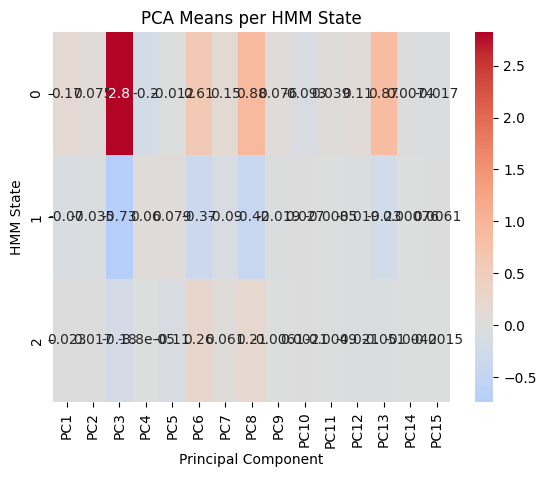

In [76]:
for i in range(model.n_components):
    total_var = np.sum(np.diag(model.covars_[i]))
    print(f"State {i} total variance: {total_var:.2f}")

pc_means = pd.DataFrame(model.means_, columns=[f'PC{i+1}' for i in range(model.means_.shape[1])])
print(pc_means)

sns.heatmap(pc_means.drop(columns='regime', errors='ignore'), annot=True, cmap='coolwarm', center=0)
plt.title("PCA Means per HMM State")
plt.xlabel("Principal Component")
plt.ylabel("HMM State")
plt.show()

In [77]:
hidden_states = model.predict(X)
data.loc[:, 'regime'] = hidden_states

In [78]:
state_map = {
    0: 'high_vol',
    1: 'low_vol',
    2: 'trending'
}

data['regime_label'] = data['regime'].map(state_map)

In [79]:
print(data['regime_label'].value_counts())

regime_label
low_vol     3001551
trending    2125306
high_vol     914441
Name: count, dtype: int64


In [84]:
jl.dump({
    'model': model,
    'scaler': scaler,
    'pca' : pca,
    'map': state_map
}, 'regime_hmm_scaler.pkl')

['regime_hmm_scaler.pkl']